# Kriging the short dataset

In [1]:
from importlib import reload
try:
    reload(kriging)
    from kriging import Kriging
except:
    import kriging
    reload(kriging)
    from kriging import Kriging
import numpy as np
import matplotlib.pyplot as plt

import time

In [2]:
freqarr, freqstep = np.linspace(0,250,4096,retstep=True) # Based on number of frequency channels of the antenna
# minfreq = 30
# maxfreq = 200
# minfreqarg = int(minfreq/freqstep)
# maxfreqarg = int(maxfreq/freqstep)
print(freqstep)
print(freqarr[2000:2002])
freq = 100 # MHz
freq_index = int(freq/freqstep)
print(freq_index)

0.06105006105006105
[122.1001221  122.16117216]
1638


In [3]:
# Load in the data
year = '2021'
instrument = '100MHz'
channel = 'NS'

datadir = '../test_data/'+year+'/'+instrument+'/'+channel+'/'

save_mask = np.load(datadir+'shortdata_'+year+'_'+instrument+'_'+channel+'_mask.npy')
dat=np.load(datadir+'shortdata_meas_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask]
lst=np.load(datadir+'shortlst_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask]
t=np.load(datadir+'shortsystime_'+year+'_'+instrument+'_'+channel+'.npy')[save_mask]
t_ant = np.load(datadir+'antsystime_'+year+'_'+instrument+'_'+channel+'.npy')

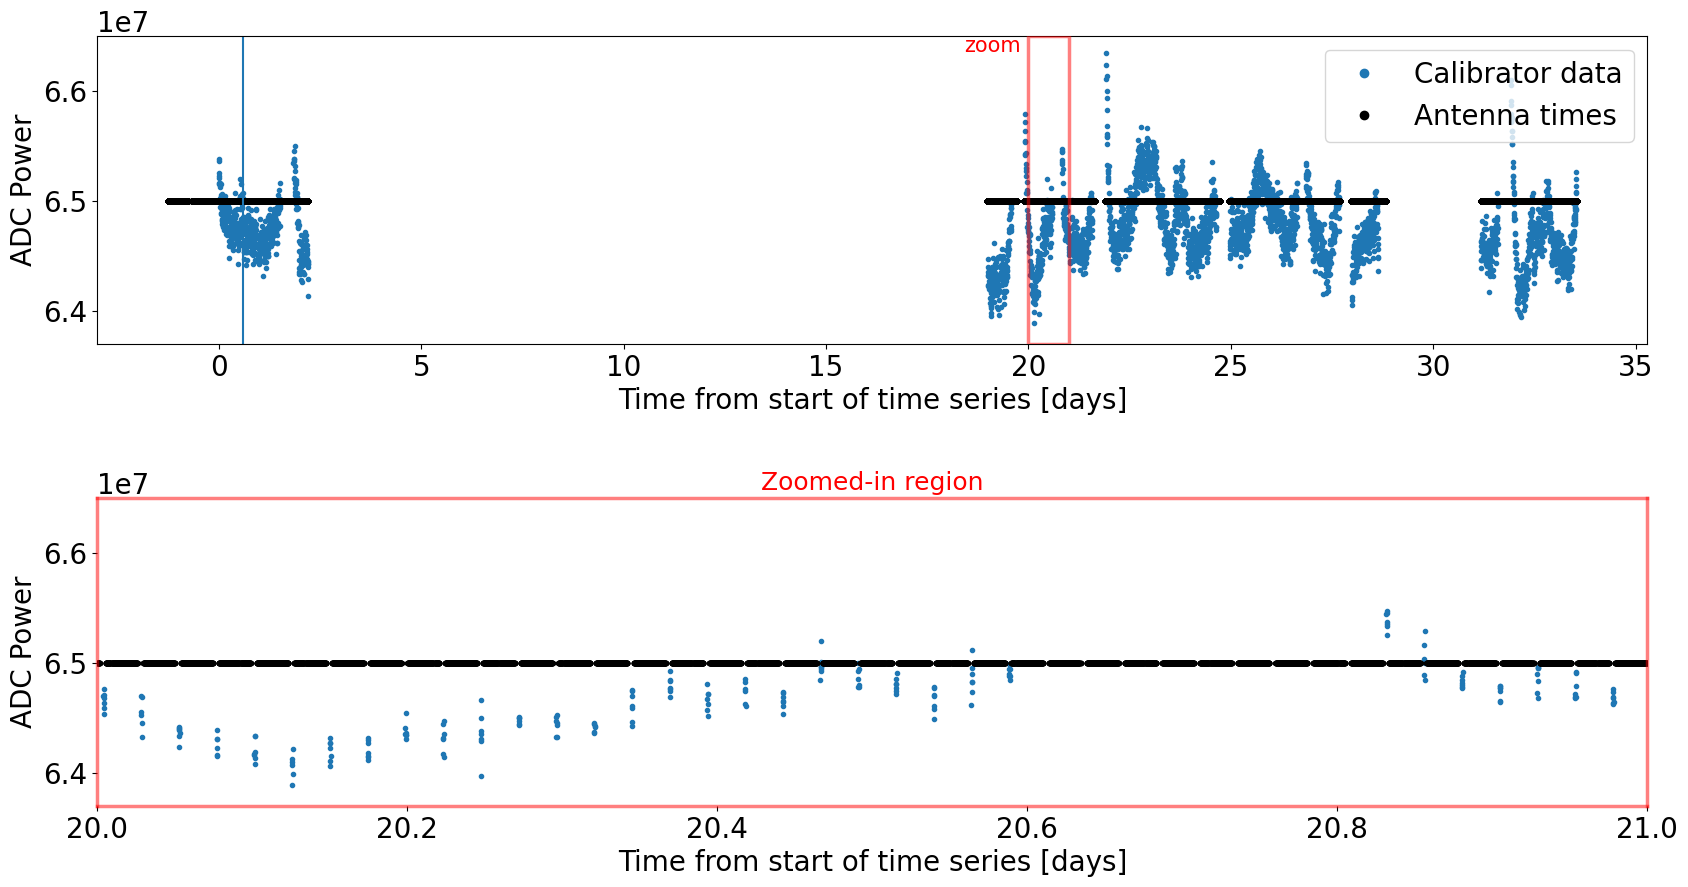

In [4]:
# Optional: select a subset of the data (mostly for testing)
# tmax=1.6374e9
# tmin=1.6365e9
# tmax=1.636e9
tmax=np.inf
tmin=0

mask=(t>tmin)&(t<tmax)
tt=t[mask]
dd=dat[mask,:]

ant_mask = (t_ant>tmin)&(t_ant<tmax)
tt_ant = t_ant[ant_mask]

# Pick a freq_index to plot (the fit is done for all frequencies)
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(20,10))
plt.subplots_adjust(hspace=0.5)

# Main plot
ax[0].plot((tt-tt[0])/(3600*24),dd[:,freq_index],'.',label='Calibrator data')
ax[0].plot((tt_ant-tt[0])/(3600*24),[6.5e7 for ti in tt_ant],'.',color='black',label='Antenna times')
# plt.title('Short Calibrator Data and Antenna Times To Interpolate To\nFrequency Channel = '+str(freq)+'MHz')
# plt.xlim(left=-40,right=60)
# plt.xlim(left=450)
ax[0].set_xlabel('Time from start of time series [days]')
ax[0].set_ylabel('ADC Power')
ax[0].set_ylim(6.37e7,6.65e7)
ax[0].legend(loc='upper right',markerscale=2)

# Zoomed plot
zoom_start = 20 # days
zoom_end = 21
zoom_ylim = (6.37e7,6.65e7)
ax[1].plot((tt-tt[0])/(3600*24),dd[:,freq_index],'.',label='Calibrator data')
ax[1].plot((tt_ant-tt[0])/(3600*24),[6.5e7 for ti in tt_ant],'.',color='black',label='Antenna times')
ax[1].set_xlim(zoom_start, zoom_end)
ax[1].set_ylim(*zoom_ylim)
# ax[2].set_yticks(custom_tick_positions)
# ax[2].set_yticklabels(custom_tick_labels)
# ax[2].set_xlabel('UNIX Timestamp [s]')
ax[1].set_xlabel('Time from start of time series [days]')
ax[1].set_ylabel('ADC Power')
ax[1].set_title("Zoomed-in region",fontsize=18,color='red')

from matplotlib.patches import Patch, Rectangle
# Add rectangle to ax2 to indicate zoomed-in area
highlight_rect = Rectangle(
    (zoom_start, zoom_ylim[0]),                    # (x0, y0)
    width=zoom_end - zoom_start,                   # width in datetime
    height=zoom_ylim[1]-0.01 - zoom_ylim[0],            # height
    linewidth=2.5,
    edgecolor='red',
    facecolor='none',
    alpha=0.5,
    linestyle='-',
    zorder=100 # in front of everything else
)
ax[0].add_patch(highlight_rect)

# Match zoomed-in subplot outline to box color
for spine in ax[1].spines.values():
    spine.set_edgecolor((1, 0, 0, 0.5))
    spine.set_linewidth(2.5)
    spine

# Coordinates for top-right corner of the rectangle
label_x = zoom_start-0.2
label_y = zoom_ylim[1]

# Add "zoom" text inside the rectangle
ax[0].text(
    label_x, label_y, 'zoom',
    color='red',
    fontsize=15,
    ha='right', va='top',
    zorder=101  # ensure it sits above the rectangle
)

ax[0].vlines(x=(tt_ant[20000]-tt[0])/(3600*24),ymin=6.3e7,ymax=6.7e7)
# plt.savefig('PreInterp-2021-100-NS-100MHzchan-short-zoombox.jpg',bbox_inches='tight',dpi=300)
plt.show()

In [5]:
# Step 1: Initialize Kriging class
# You can actually pass tmax and tmin to the Kriging object and it'll select for you
krig_object = Kriging(systime=t,data=dat,interp_times=t_ant,tmax_mask=tmax,tmin_mask=tmin,
                      minfreq=100,maxfreq=100) # right now just one time

In [6]:
# Step 2: Call the object to perform the Kriging
tstart = time.time()
krig_object(dt=5,dtmax=10*3600,acf_functype='quadpeak') # dt and dtmax in seconds
tend = time.time()
print('Time taken:',tend-tstart,'sec')

Verifying freq args are the same within kriging object: min 1638 , max 1638
100.0 MHz channel done
Time taken: 58.47744274139404 sec


In [7]:
slct = 0
rslt = krig_object.interp_data[slct]
print(rslt)
err = krig_object.interp_std[slct]
avgd_time = krig_object.save_avgd_time[slct]
avgd_data = krig_object.save_avgd_data[slct]
avgd_data_std = krig_object.save_avgd_data_std[slct]
print(len(t_ant))
print(len(t))

# Saving some testing data
# rslt_nonavgd = krig_object.interp_data[slct]
# err_nonavgd = krig_object.interp_std[slct]
plt.plot(tt_ant,(rslt-rslt_nonavgd)/rslt *100)
plt.show()

[              nan               nan               nan ...
 64981139.0866219  64981074.28800453 64981004.77206396]
165328
3294


NameError: name 'rslt_nonavgd' is not defined

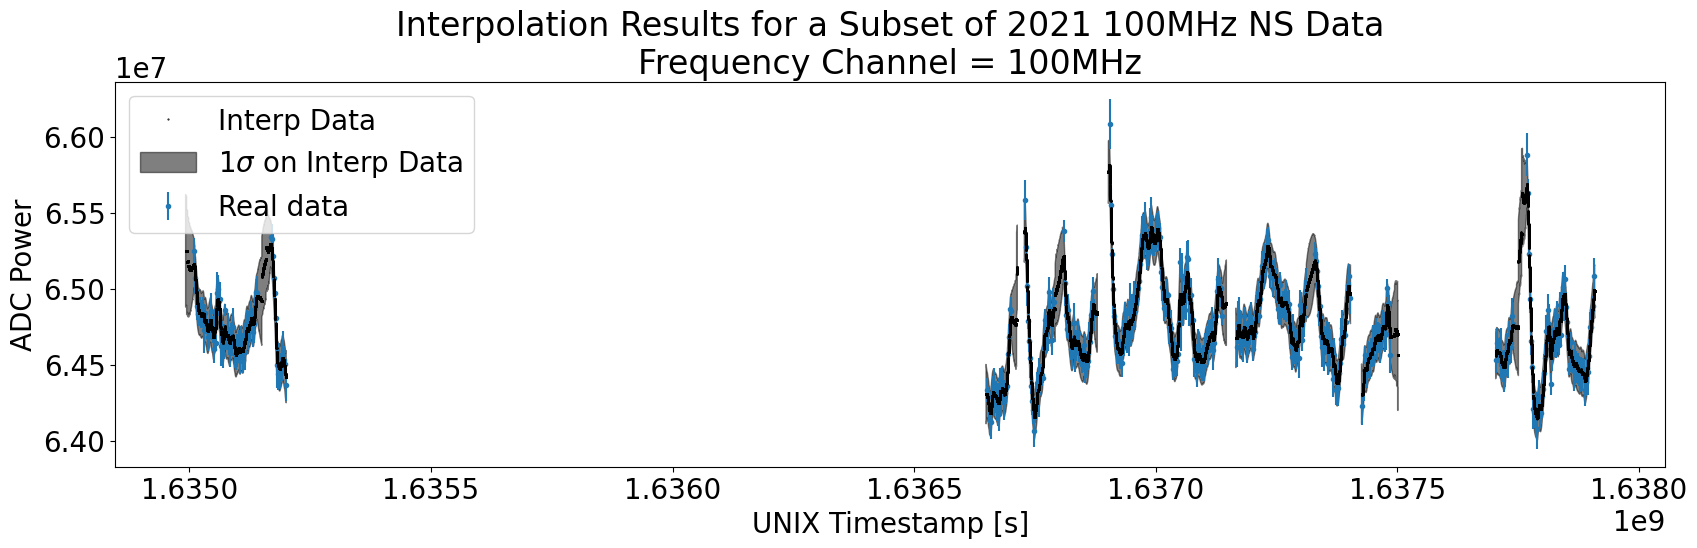

In [8]:
fig = plt.figure(figsize=(20,5))
plt.rcParams.update({'font.size': 20})

# Select frequency ------
freq = 100 # MHz
freq_index = int(freq/freqstep)
# -----------------------

# Plot the averaged data with error bars
x = tt_ant
y1 = (rslt-err)
y2 = (rslt+err)

gap_threshold = 60*60 # 1h gap threshold
mask = np.ediff1d(x, to_begin=0) > gap_threshold

x_masked = np.ma.masked_where(mask, x)
y1_masked = np.ma.masked_where(mask, y1)
y2_masked = np.ma.masked_where(mask, y2)

plt.errorbar(x=avgd_time,y=avgd_data,yerr=avgd_data_std,marker='.',label='Real data',ls='none',zorder=1)

# Plot the results of the interpolation at antenna times
plt.plot(tt_ant,rslt,'.',ms=1,label='Interp Data',color='k',zorder=2)
plt.fill_between(x_masked,y1_masked,y2_masked,alpha=0.5,color='k',zorder=0,label=r'1$\sigma$ on Interp Data')

# plt.ylim(bottom=7e7)
plt.xlabel('UNIX Timestamp [s]')
plt.ylabel('ADC Power')
plt.legend()
plt.title('Interpolation Results for a Subset of '+year+' '+instrument+' '+channel+' Data\nFrequency Channel = '+str(freq)+'MHz')
# plt.plot(tt_ant,[6.6e7 for ti in tt_ant],'.',color='red',label='Antenna times (interp times)')
# plt.xlim(left= 1.6365e9,right=1.6380e9)
# plt.ylim(top=6.9e7,bottom=6.4e7)
# plt.savefig('InterpRslt',dpi=300)
plt.show()

In [24]:
# Get linear interpolation result from the current pipeline calibrator interpolation scheme
from data_prep import DataPrep
dp = DataPrep(instrument,channel,year)
old_lin_interp = dp.shorts

Returning default mask
Returning default mask


In [17]:
old_lin_interp.shape

(165328, 4096)

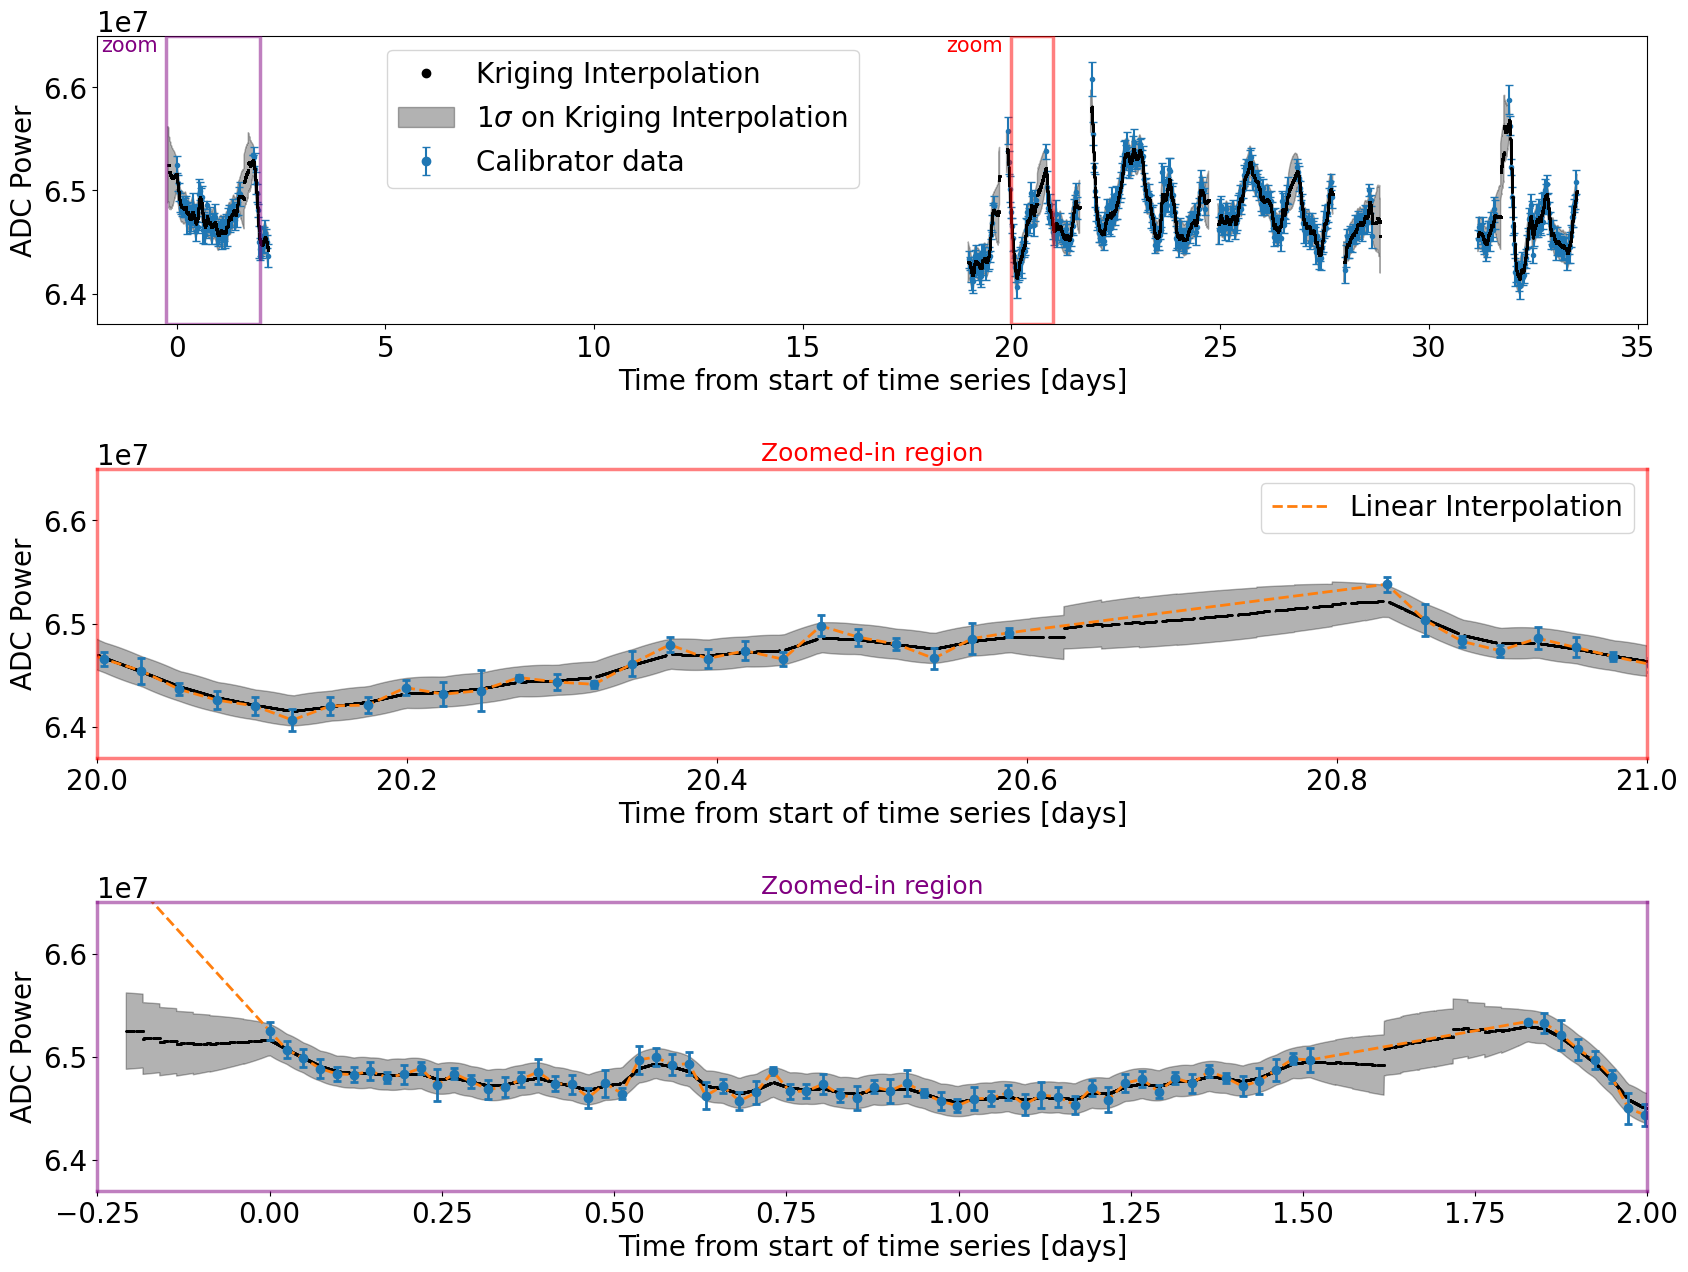

In [33]:
# Optional: select a subset of the data (mostly for testing)
from matplotlib.lines import Line2D
# Pick a freq_index to plot (the fit is done for all frequencies)
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(20,15))
plt.subplots_adjust(hspace=0.5)

# Main plot
ax[0].plot((tt_ant-tt[0])/(3600*24),rslt,'.',ms=1,label='Kriging Interpolation',color='k',zorder=2)
ax[0].fill_between((x_masked-tt[0])/(3600*24),y1_masked,y2_masked,alpha=0.3,color='k',zorder=0,label=r'1$\sigma$ on Kriging Interpolation')
ax[0].errorbar(x=(avgd_time-tt[0])/(3600*24),y=avgd_data,yerr=avgd_data_std,marker='.',label='Calibrator data',ls='none',zorder=1,capsize=3)
# ax[0].plot((tt-tt[0])/(3600*24),dd[:,freq_index],'.',label='Calibrator data',zorder=0)
# ax[0].plot((tt_ant-tt[0])/(3600*24),[6.5e7 for ti in tt_ant],'.',color='black',label='Antenna times')
# plt.title('Short Calibrator Data and Antenna Times To Interpolate To\nFrequency Channel = '+str(freq)+'MHz')
# plt.xlim(left=-40,right=60)
# plt.xlim(left=450)
ax[0].set_xlabel('Time from start of time series [days]')
ax[0].set_ylabel('ADC Power')
ax[0].set_ylim(6.37e7,6.65e7)
handles, labels = ax[0].get_legend_handles_labels()
custom_index = labels.index('Kriging Interpolation')
handles[custom_index] = Line2D(
    [0], [0], marker='.', color='k', linestyle='None',
    markersize=6, label='Kriging Interpolation'
)
ax[0].legend(handles=handles, labels=labels,markerscale=2,bbox_to_anchor=(0.5, 1.0))

# Zoomed plot
zoom_start = 20 # days
zoom_end = 21
zoom_ylim = (6.37e7,6.65e7)
ax[1].plot((tt_ant-tt[0])/(3600*24),rslt,'.',ms=1,label='Kriging Interpolation',color='k',zorder=1)
ax[1].fill_between((x_masked-tt[0])/(3600*24),y1_masked,y2_masked,alpha=0.3,color='k',zorder=0,label=r'1$\sigma$ on Kriging Interpolation')
ax[1].errorbar(x=(avgd_time-tt[0])/(3600*24),y=avgd_data,yerr=avgd_data_std,marker='o',label='Calibrator data',ls='none',zorder=2,capsize=3,elinewidth=2,capthick=2)
# ax[1].plot((tt-tt[0])/(3600*24),dd[:,freq_index],'.',label='Calibrator data')

ax[1].set_xlim(zoom_start, zoom_end)
ax[1].set_ylim(*zoom_ylim)
# ax[2].set_yticks(custom_tick_positions)
# ax[2].set_yticklabels(custom_tick_labels)
# ax[2].set_xlabel('UNIX Timestamp [s]')
ax[1].set_xlabel('Time from start of time series [days]')
ax[1].set_ylabel('ADC Power')
ax[1].set_title("Zoomed-in region",fontsize=18,color='red')

from matplotlib.patches import Patch, Rectangle
# Add rectangle to ax2 to indicate zoomed-in area
highlight_rect = Rectangle(
    (zoom_start, zoom_ylim[0]),                    # (x0, y0)
    width=zoom_end - zoom_start,                   # width in datetime
    height=zoom_ylim[1]-0.01 - zoom_ylim[0],            # height
    linewidth=2.5,
    edgecolor='red',
    facecolor='none',
    alpha=0.5,
    linestyle='-',
    zorder=100 # in front of everything else
)
ax[0].add_patch(highlight_rect)

# Match zoomed-in subplot outline to box color
for spine in ax[1].spines.values():
    spine.set_edgecolor((1, 0, 0, 0.5))
    spine.set_linewidth(2.5)
    spine

# Coordinates for top-right corner of the rectangle
label_x = zoom_start-0.2
label_y = zoom_ylim[1]

# Add "zoom" text inside the rectangle
ax[0].text(
    label_x, label_y, 'zoom',
    color='red',
    fontsize=15,
    ha='right', va='top',
    zorder=101  # ensure it sits above the rectangle
)

# Zoomed plot 2
zoom_start = -0.25 # days
zoom_end = 2
zoom_ylim = (6.37e7,6.65e7)
ax[2].plot((tt_ant-tt[0])/(3600*24),rslt,'.',ms=1,label='Kriging Interpolation',color='k',zorder=1)
ax[2].fill_between((x_masked-tt[0])/(3600*24),y1_masked,y2_masked,alpha=0.3,color='k',zorder=0,label=r'1$\sigma$ on Kriging Interpolation')
ax[2].errorbar(x=(avgd_time-tt[0])/(3600*24),y=avgd_data,yerr=avgd_data_std,marker='o',label='Calibrator data',ls='none',zorder=2,capsize=3,elinewidth=2,capthick=2)
# ax[2].plot((tt-tt[0])/(3600*24),dd[:,freq_index],'.',label='Calibrator data')

ax[2].set_xlim(zoom_start, zoom_end)
ax[2].set_ylim(*zoom_ylim)
# ax[2].set_yticks(custom_tick_positions)
# ax[2].set_yticklabels(custom_tick_labels)
# ax[2].set_xlabel('UNIX Timestamp [s]')
ax[2].set_xlabel('Time from start of time series [days]')
ax[2].set_ylabel('ADC Power')
ax[2].set_title("Zoomed-in region",fontsize=18,color='purple')

# Add rectangle to ax2 to indicate zoomed-in area
highlight_rect = Rectangle(
    (zoom_start, zoom_ylim[0]),                    # (x0, y0)
    width=zoom_end - zoom_start,                   # width in datetime
    height=zoom_ylim[1]-0.01 - zoom_ylim[0],            # height
    linewidth=2.5,
    edgecolor='purple',
    facecolor='none',
    alpha=0.5,
    linestyle='-',
    zorder=100 # in front of everything else
)
ax[0].add_patch(highlight_rect)

# Match zoomed-in subplot outline to box color
for spine in ax[2].spines.values():
    spine.set_edgecolor((0.5, 0, 0.5, 0.5))
    spine.set_linewidth(2.5)
    spine

# Coordinates for top-right corner of the rectangle
label_x = zoom_start-0.2
label_y = zoom_ylim[1]

# Add "zoom" text inside the rectangle
ax[0].text(
    label_x, label_y, 'zoom',
    color='purple',
    fontsize=15,
    ha='right', va='top',
    zorder=101  # ensure it sits above the rectangle
)

# Overplot linear interpolation to compare to kriging result
# ax[1].plot((tt_ant-tt[0])/(3600*24),np.interp((tt_ant-tt[0])/(3600*24),(avgd_time-tt[0])/(3600*24),avgd_data),label='Linear Interp',ls='--',marker='none')
# ax[2].plot((tt_ant-tt[0])/(3600*24),np.interp((tt_ant-tt[0])/(3600*24),(avgd_time-tt[0])/(3600*24),avgd_data),label='Linear Interp',ls='--',marker='none')
ax[1].plot((tt_ant-tt[0])/(3600*24),old_lin_interp[:,freq_index],label='Linear Interpolation',ls='--',lw=2,marker='none')
ax[2].plot((tt_ant-tt[0])/(3600*24),old_lin_interp[:,freq_index],label='Linear Interpolation',ls='--',lw=2,marker='none')


# ax[1].plot((tt_ant-tt[0])/(3600*24),np.interp((tt_ant-tt[0])/(3600*24),(tt-tt[0])/(3600*24),dd[:,freq_index]),label='Linear Interp',ls='--',marker='none')
# ax[2].plot((tt_ant-tt[0])/(3600*24),np.interp((tt_ant-tt[0])/(3600*24),(tt-tt[0])/(3600*24),dd[:,freq_index]),label='Linear Interp',ls='--',marker='none')

handles, labels = ax[1].get_legend_handles_labels()
# ax[0].legend(handles=handles, labels=labels,markerscale=2,bbox_to_anchor=(0.4, 1.0))
ax[1].legend([handles[-2]], [labels[-2]], loc="best")
# print(handles,labels)

# plt.savefig('PostInterp-2021-100-NS-100MHzchan-short-WITHLININTERP.jpg',bbox_inches='tight',dpi=300)
plt.show()

## Using a fit to a longer range of the ACF for Kriging

Notably a B-spline.

In [27]:
import kriging_modified_fits
reload(kriging_modified_fits)
from kriging_modified_fits import Kriging

In [28]:
# Step 1: Initialize Kriging class
# You can actually pass tmax and tmin to the Kriging object and it'll select for you
krig_object = Kriging(systime=t,data=dat,interp_times=t_ant,tmax_mask=tmax,tmin_mask=tmin,
                      minfreq=100,maxfreq=100) # right now just one time

Verifying freq args are the same within kriging object: min 1638 , max 1638


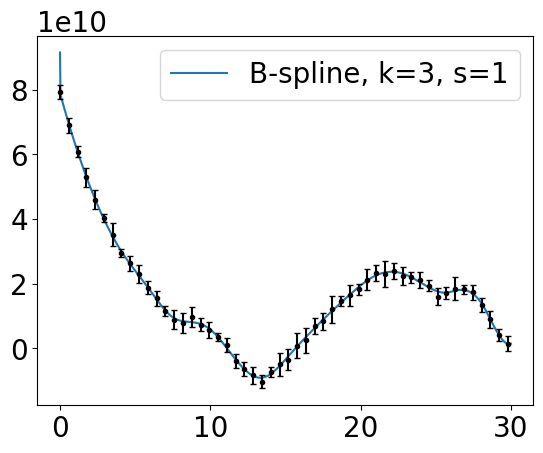

100.0 MHz channel done
Time taken: 221.1666579246521 sec


In [29]:
# Step 2: Call the object to perform the Kriging
tstart = time.time()
krig_object(dt=5,dtmax=30*3600,acf_functype='Bspline') # dt and dtmax in seconds
tend = time.time()
print('Time taken:',tend-tstart,'sec')

In [30]:
slct = 0
rslt = krig_object.interp_data[slct]
print(rslt)
err = krig_object.interp_std[slct]
avgd_time = krig_object.save_avgd_time[slct]
avgd_data = krig_object.save_avgd_data[slct]
avgd_data_std = krig_object.save_avgd_data_std[slct]

[              nan               nan               nan ...
 64972099.37910166 64971983.49051929 64971859.06644534]


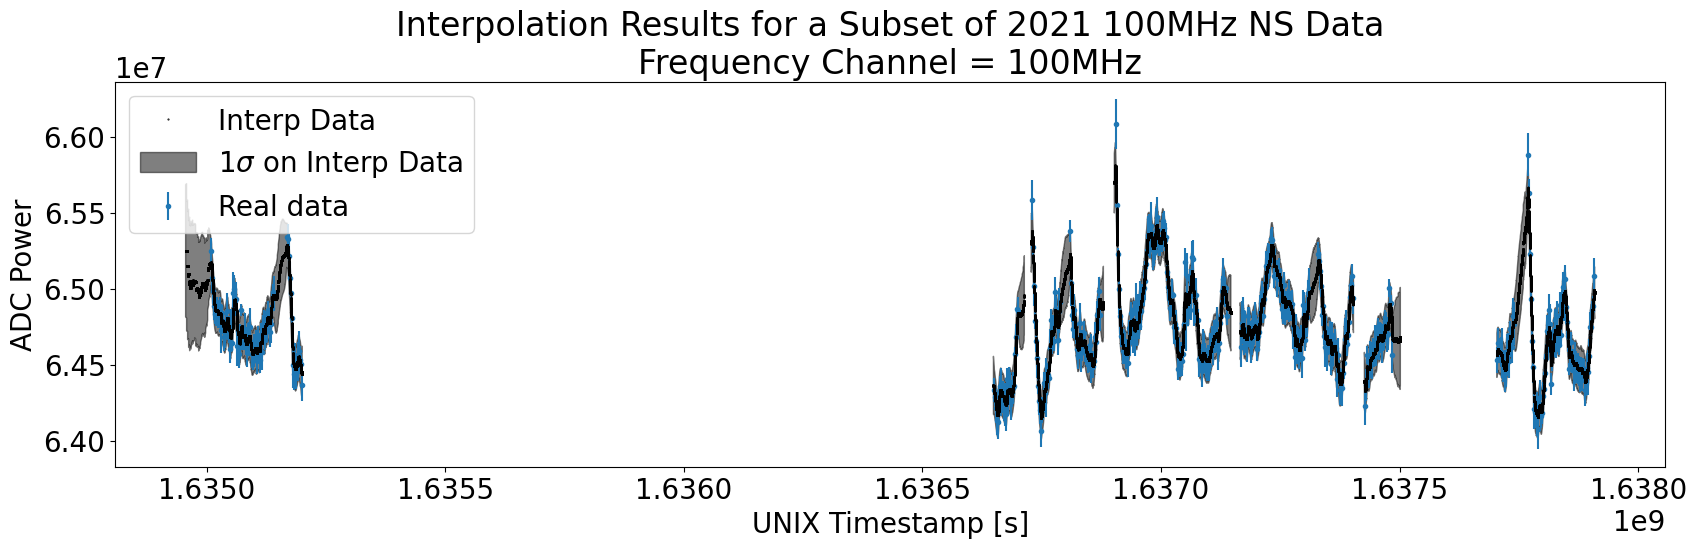

In [31]:
fig = plt.figure(figsize=(20,5))
plt.rcParams.update({'font.size': 20})

# Select frequency ------
freq = 100 # MHz
freq_index = int(freq/freqstep)
# -----------------------

# Plot the averaged data with error bars
x = tt_ant
y1 = (rslt-err)
y2 = (rslt+err)

gap_threshold = 60*60 # 1h gap threshold
mask = np.ediff1d(x, to_begin=0) > gap_threshold

x_masked = np.ma.masked_where(mask, x)
y1_masked = np.ma.masked_where(mask, y1)
y2_masked = np.ma.masked_where(mask, y2)

plt.errorbar(x=avgd_time,y=avgd_data,yerr=avgd_data_std,marker='.',label='Real data',ls='none',zorder=1)

# Plot the results of the interpolation at antenna times
plt.plot(tt_ant,rslt,'.',ms=1,label='Interp Data',color='k',zorder=2)
plt.fill_between(x_masked,y1_masked,y2_masked,alpha=0.5,color='k',zorder=0,label=r'1$\sigma$ on Interp Data')

# plt.ylim(bottom=7e7)
plt.xlabel('UNIX Timestamp [s]')
plt.ylabel('ADC Power')
plt.legend()
plt.title('Interpolation Results for a Subset of '+year+' '+instrument+' '+channel+' Data\nFrequency Channel = '+str(freq)+'MHz')
# plt.plot(tt_ant,[6.6e7 for ti in tt_ant],'.',color='red',label='Antenna times (interp times)')
# plt.xlim(left= 1.6365e9,right=1.6380e9)
# plt.ylim(top=6.9e7,bottom=6.4e7)
# plt.savefig('InterpRslt',dpi=300)
plt.show()

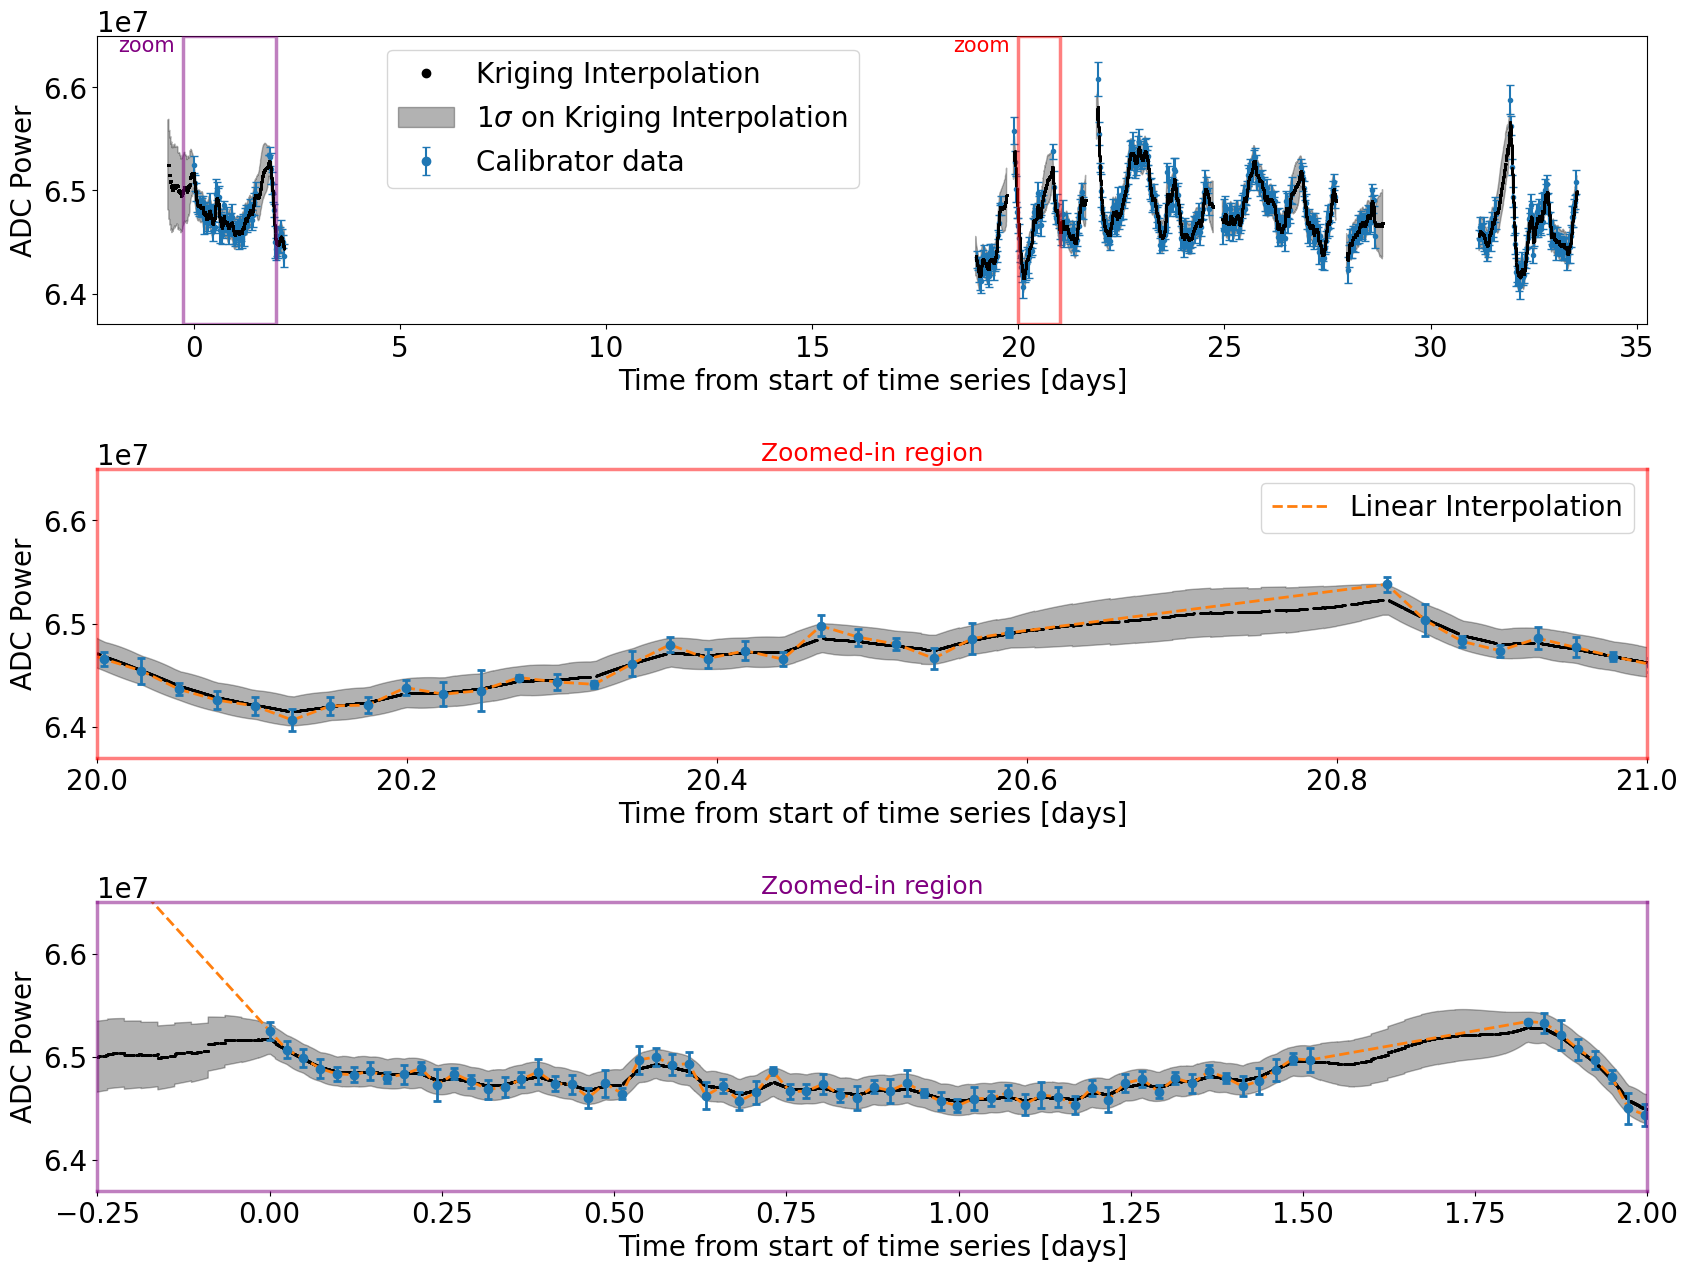

In [32]:
# Optional: select a subset of the data (mostly for testing)
from matplotlib.lines import Line2D
# Pick a freq_index to plot (the fit is done for all frequencies)
plt.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(nrows=3,ncols=1,figsize=(20,15))
plt.subplots_adjust(hspace=0.5)

# Main plot
ax[0].plot((tt_ant-tt[0])/(3600*24),rslt,'.',ms=1,label='Kriging Interpolation',color='k',zorder=2)
ax[0].fill_between((x_masked-tt[0])/(3600*24),y1_masked,y2_masked,alpha=0.3,color='k',zorder=0,label=r'1$\sigma$ on Kriging Interpolation')
ax[0].errorbar(x=(avgd_time-tt[0])/(3600*24),y=avgd_data,yerr=avgd_data_std,marker='.',label='Calibrator data',ls='none',zorder=1,capsize=3)
# ax[0].plot((tt-tt[0])/(3600*24),dd[:,freq_index],'.',label='Calibrator data',zorder=0)
# ax[0].plot((tt_ant-tt[0])/(3600*24),[6.5e7 for ti in tt_ant],'.',color='black',label='Antenna times')
# plt.title('Short Calibrator Data and Antenna Times To Interpolate To\nFrequency Channel = '+str(freq)+'MHz')
# plt.xlim(left=-40,right=60)
# plt.xlim(left=450)
ax[0].set_xlabel('Time from start of time series [days]')
ax[0].set_ylabel('ADC Power')
ax[0].set_ylim(6.37e7,6.65e7)
handles, labels = ax[0].get_legend_handles_labels()
custom_index = labels.index('Kriging Interpolation')
handles[custom_index] = Line2D(
    [0], [0], marker='.', color='k', linestyle='None',
    markersize=6, label='Kriging Interpolation'
)
ax[0].legend(handles=handles, labels=labels,markerscale=2,bbox_to_anchor=(0.5, 1.0))

# Zoomed plot
zoom_start = 20 # days
zoom_end = 21
zoom_ylim = (6.37e7,6.65e7)
ax[1].plot((tt_ant-tt[0])/(3600*24),rslt,'.',ms=1,label='Kriging Interpolation',color='k',zorder=1)
ax[1].fill_between((x_masked-tt[0])/(3600*24),y1_masked,y2_masked,alpha=0.3,color='k',zorder=0,label=r'1$\sigma$ on Kriging Interpolation')
ax[1].errorbar(x=(avgd_time-tt[0])/(3600*24),y=avgd_data,yerr=avgd_data_std,marker='o',label='Calibrator data',ls='none',zorder=2,capsize=3,elinewidth=2,capthick=2)
# ax[1].plot((tt-tt[0])/(3600*24),dd[:,freq_index],'.',label='Calibrator data')

ax[1].set_xlim(zoom_start, zoom_end)
ax[1].set_ylim(*zoom_ylim)
# ax[2].set_yticks(custom_tick_positions)
# ax[2].set_yticklabels(custom_tick_labels)
# ax[2].set_xlabel('UNIX Timestamp [s]')
ax[1].set_xlabel('Time from start of time series [days]')
ax[1].set_ylabel('ADC Power')
ax[1].set_title("Zoomed-in region",fontsize=18,color='red')

from matplotlib.patches import Patch, Rectangle
# Add rectangle to ax2 to indicate zoomed-in area
highlight_rect = Rectangle(
    (zoom_start, zoom_ylim[0]),                    # (x0, y0)
    width=zoom_end - zoom_start,                   # width in datetime
    height=zoom_ylim[1]-0.01 - zoom_ylim[0],            # height
    linewidth=2.5,
    edgecolor='red',
    facecolor='none',
    alpha=0.5,
    linestyle='-',
    zorder=100 # in front of everything else
)
ax[0].add_patch(highlight_rect)

# Match zoomed-in subplot outline to box color
for spine in ax[1].spines.values():
    spine.set_edgecolor((1, 0, 0, 0.5))
    spine.set_linewidth(2.5)
    spine

# Coordinates for top-right corner of the rectangle
label_x = zoom_start-0.2
label_y = zoom_ylim[1]

# Add "zoom" text inside the rectangle
ax[0].text(
    label_x, label_y, 'zoom',
    color='red',
    fontsize=15,
    ha='right', va='top',
    zorder=101  # ensure it sits above the rectangle
)

# Zoomed plot 2
zoom_start = -0.25 # days
zoom_end = 2
zoom_ylim = (6.37e7,6.65e7)
ax[2].plot((tt_ant-tt[0])/(3600*24),rslt,'.',ms=1,label='Kriging Interpolation',color='k',zorder=1)
ax[2].fill_between((x_masked-tt[0])/(3600*24),y1_masked,y2_masked,alpha=0.3,color='k',zorder=0,label=r'1$\sigma$ on Kriging Interpolation')
ax[2].errorbar(x=(avgd_time-tt[0])/(3600*24),y=avgd_data,yerr=avgd_data_std,marker='o',label='Calibrator data',ls='none',zorder=2,capsize=3,elinewidth=2,capthick=2)
# ax[2].plot((tt-tt[0])/(3600*24),dd[:,freq_index],'.',label='Calibrator data')

ax[2].set_xlim(zoom_start, zoom_end)
ax[2].set_ylim(*zoom_ylim)
# ax[2].set_yticks(custom_tick_positions)
# ax[2].set_yticklabels(custom_tick_labels)
# ax[2].set_xlabel('UNIX Timestamp [s]')
ax[2].set_xlabel('Time from start of time series [days]')
ax[2].set_ylabel('ADC Power')
ax[2].set_title("Zoomed-in region",fontsize=18,color='purple')

# Add rectangle to ax2 to indicate zoomed-in area
highlight_rect = Rectangle(
    (zoom_start, zoom_ylim[0]),                    # (x0, y0)
    width=zoom_end - zoom_start,                   # width in datetime
    height=zoom_ylim[1]-0.01 - zoom_ylim[0],            # height
    linewidth=2.5,
    edgecolor='purple',
    facecolor='none',
    alpha=0.5,
    linestyle='-',
    zorder=100 # in front of everything else
)
ax[0].add_patch(highlight_rect)

# Match zoomed-in subplot outline to box color
for spine in ax[2].spines.values():
    spine.set_edgecolor((0.5, 0, 0.5, 0.5))
    spine.set_linewidth(2.5)
    spine

# Coordinates for top-right corner of the rectangle
label_x = zoom_start-0.2
label_y = zoom_ylim[1]

# Add "zoom" text inside the rectangle
ax[0].text(
    label_x, label_y, 'zoom',
    color='purple',
    fontsize=15,
    ha='right', va='top',
    zorder=101  # ensure it sits above the rectangle
)

# Overplot linear interpolation to compare to kriging result
# ax[1].plot((tt_ant-tt[0])/(3600*24),np.interp((tt_ant-tt[0])/(3600*24),(avgd_time-tt[0])/(3600*24),avgd_data),label='Linear Interp',ls='--',marker='none')
# ax[2].plot((tt_ant-tt[0])/(3600*24),np.interp((tt_ant-tt[0])/(3600*24),(avgd_time-tt[0])/(3600*24),avgd_data),label='Linear Interp',ls='--',marker='none')
ax[1].plot((tt_ant-tt[0])/(3600*24),old_lin_interp[:,freq_index],label='Linear Interpolation',ls='--',lw=2,marker='none')
ax[2].plot((tt_ant-tt[0])/(3600*24),old_lin_interp[:,freq_index],label='Linear Interpolation',ls='--',lw=2,marker='none')


# ax[1].plot((tt_ant-tt[0])/(3600*24),np.interp((tt_ant-tt[0])/(3600*24),(tt-tt[0])/(3600*24),dd[:,freq_index]),label='Linear Interp',ls='--',marker='none')
# ax[2].plot((tt_ant-tt[0])/(3600*24),np.interp((tt_ant-tt[0])/(3600*24),(tt-tt[0])/(3600*24),dd[:,freq_index]),label='Linear Interp',ls='--',marker='none')

handles, labels = ax[1].get_legend_handles_labels()
# ax[0].legend(handles=handles, labels=labels,markerscale=2,bbox_to_anchor=(0.4, 1.0))
ax[1].legend([handles[-2]], [labels[-2]], loc="best")
# print(handles,labels)

plt.savefig('PostInterp-2021-100-NS-100MHzchan-short-BSPLINE.jpg',bbox_inches='tight',dpi=300)
plt.show()